Importing required Simpson data

In [1]:
!pip install caer 


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.1/320.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.4/192.4 kB 14.2 MB/s eta 0:00:00


In [2]:
!python -m pip show caer


Name: caer
Version: 2.1.1
Summary: A lightweight Computer Vision library for high-performance AI research - Modern Computer Vision on the Fly.
Home-page: https://github.com/jasmcaus/caer
Author: Jason
Author-email: 
License: MIT License
Location: /usr/local/lib/python3.12/dist-packages
Requires: mypy, numpy, opencv-contrib-python, typing-extensions
Required-by: 


Installing required packages

In [3]:
!pip install tensorflow

In [4]:
  # !pip install canaro  # - package not available

In [5]:
import os
import caer
#import canaro
import numpy as np
import cv2 as cv
import gc  # garbage collector

In [6]:
img_size = (80, 80)
channels = 1
# path of actual data - Simpsons_dataset
char_path = r'/kaggle/input/the-simpsons-characters-dataset/simpsons_dataset'

In [7]:
# fetching top 10 characters that have more images in the dataset
char_dict = {}

for char in os.listdir(char_path):
    char_dict[char] = len(os.listdir(os.path.join(char_path, char ) ) )

# sort in ascending order

char_dict = caer.sort_dict(char_dict, descending = True)
char_dict

[('homer_simpson', 2246),
 ('ned_flanders', 1454),
 ('moe_szyslak', 1452),
 ('lisa_simpson', 1354),
 ('bart_simpson', 1342),
 ('marge_simpson', 1291),
 ('krusty_the_clown', 1206),
 ('principal_skinner', 1194),
 ('charles_montgomery_burns', 1193),
 ('milhouse_van_houten', 1079),
 ('chief_wiggum', 986),
 ('abraham_grampa_simpson', 913),
 ('sideshow_bob', 877),
 ('apu_nahasapeemapetilon', 623),
 ('kent_brockman', 498),
 ('comic_book_guy', 469),
 ('edna_krabappel', 457),
 ('nelson_muntz', 358),
 ('lenny_leonard', 310),
 ('mayor_quimby', 246),
 ('waylon_smithers', 181),
 ('maggie_simpson', 128),
 ('groundskeeper_willie', 121),
 ('barney_gumble', 106),
 ('selma_bouvier', 103),
 ('carl_carlson', 98),
 ('ralph_wiggum', 89),
 ('patty_bouvier', 72),
 ('martin_prince', 71),
 ('professor_john_frink', 65),
 ('snake_jailbird', 55),
 ('cletus_spuckler', 47),
 ('rainier_wolfcastle', 45),
 ('simpsons_dataset', 42),
 ('agnes_skinner', 42),
 ('sideshow_mel', 40),
 ('otto_mann', 32),
 ('fat_tony', 27),
 (

In [8]:
# printing characters name stored in list

characters = []
count = 0

for i in char_dict:
    characters.append(i[0])

    count += 1
    
    if count >= 10:
        break

characters

['homer_simpson',
 'ned_flanders',
 'moe_szyslak',
 'lisa_simpson',
 'bart_simpson',
 'marge_simpson',
 'krusty_the_clown',
 'principal_skinner',
 'charles_montgomery_burns',
 'milhouse_van_houten']

In [9]:
#  create train model
train = caer.preprocess_from_dir( char_path, 
                                 characters, 
                                 channels = channels, 
                                 IMG_SIZE = img_size, 
                                 isShuffle = True)

len(train)

[INFO] Could not find a file to load from. Generating the training data
----------------------------------------------
[INFO] At 1000 files
[INFO] At 2000 files
[INFO] 2246 files found in 5.1146979331970215s
[INFO] At 1000 files
[INFO] 1454 files found in 4.140870809555054s
[INFO] At 1000 files
[INFO] 1452 files found in 4.093893527984619s
[INFO] At 1000 files
[INFO] 1354 files found in 4.053195953369141s
[INFO] At 1000 files
[INFO] 1342 files found in 4.162914752960205s
[INFO] At 1000 files
[INFO] 1291 files found in 4.034050226211548s
[INFO] At 1000 files
[INFO] 1206 files found in 4.010007381439209s
[INFO] At 1000 files
[INFO] 1194 files found in 3.843461751937866s
[INFO] At 1000 files
[INFO] 1193 files found in 4.17334508895874s
[INFO] At 1000 files
[INFO] 1079 files found in 3.8701930046081543s
----------------------------------------------
[INFO] 13811 files preprocessed! Took 3m 51s


13811

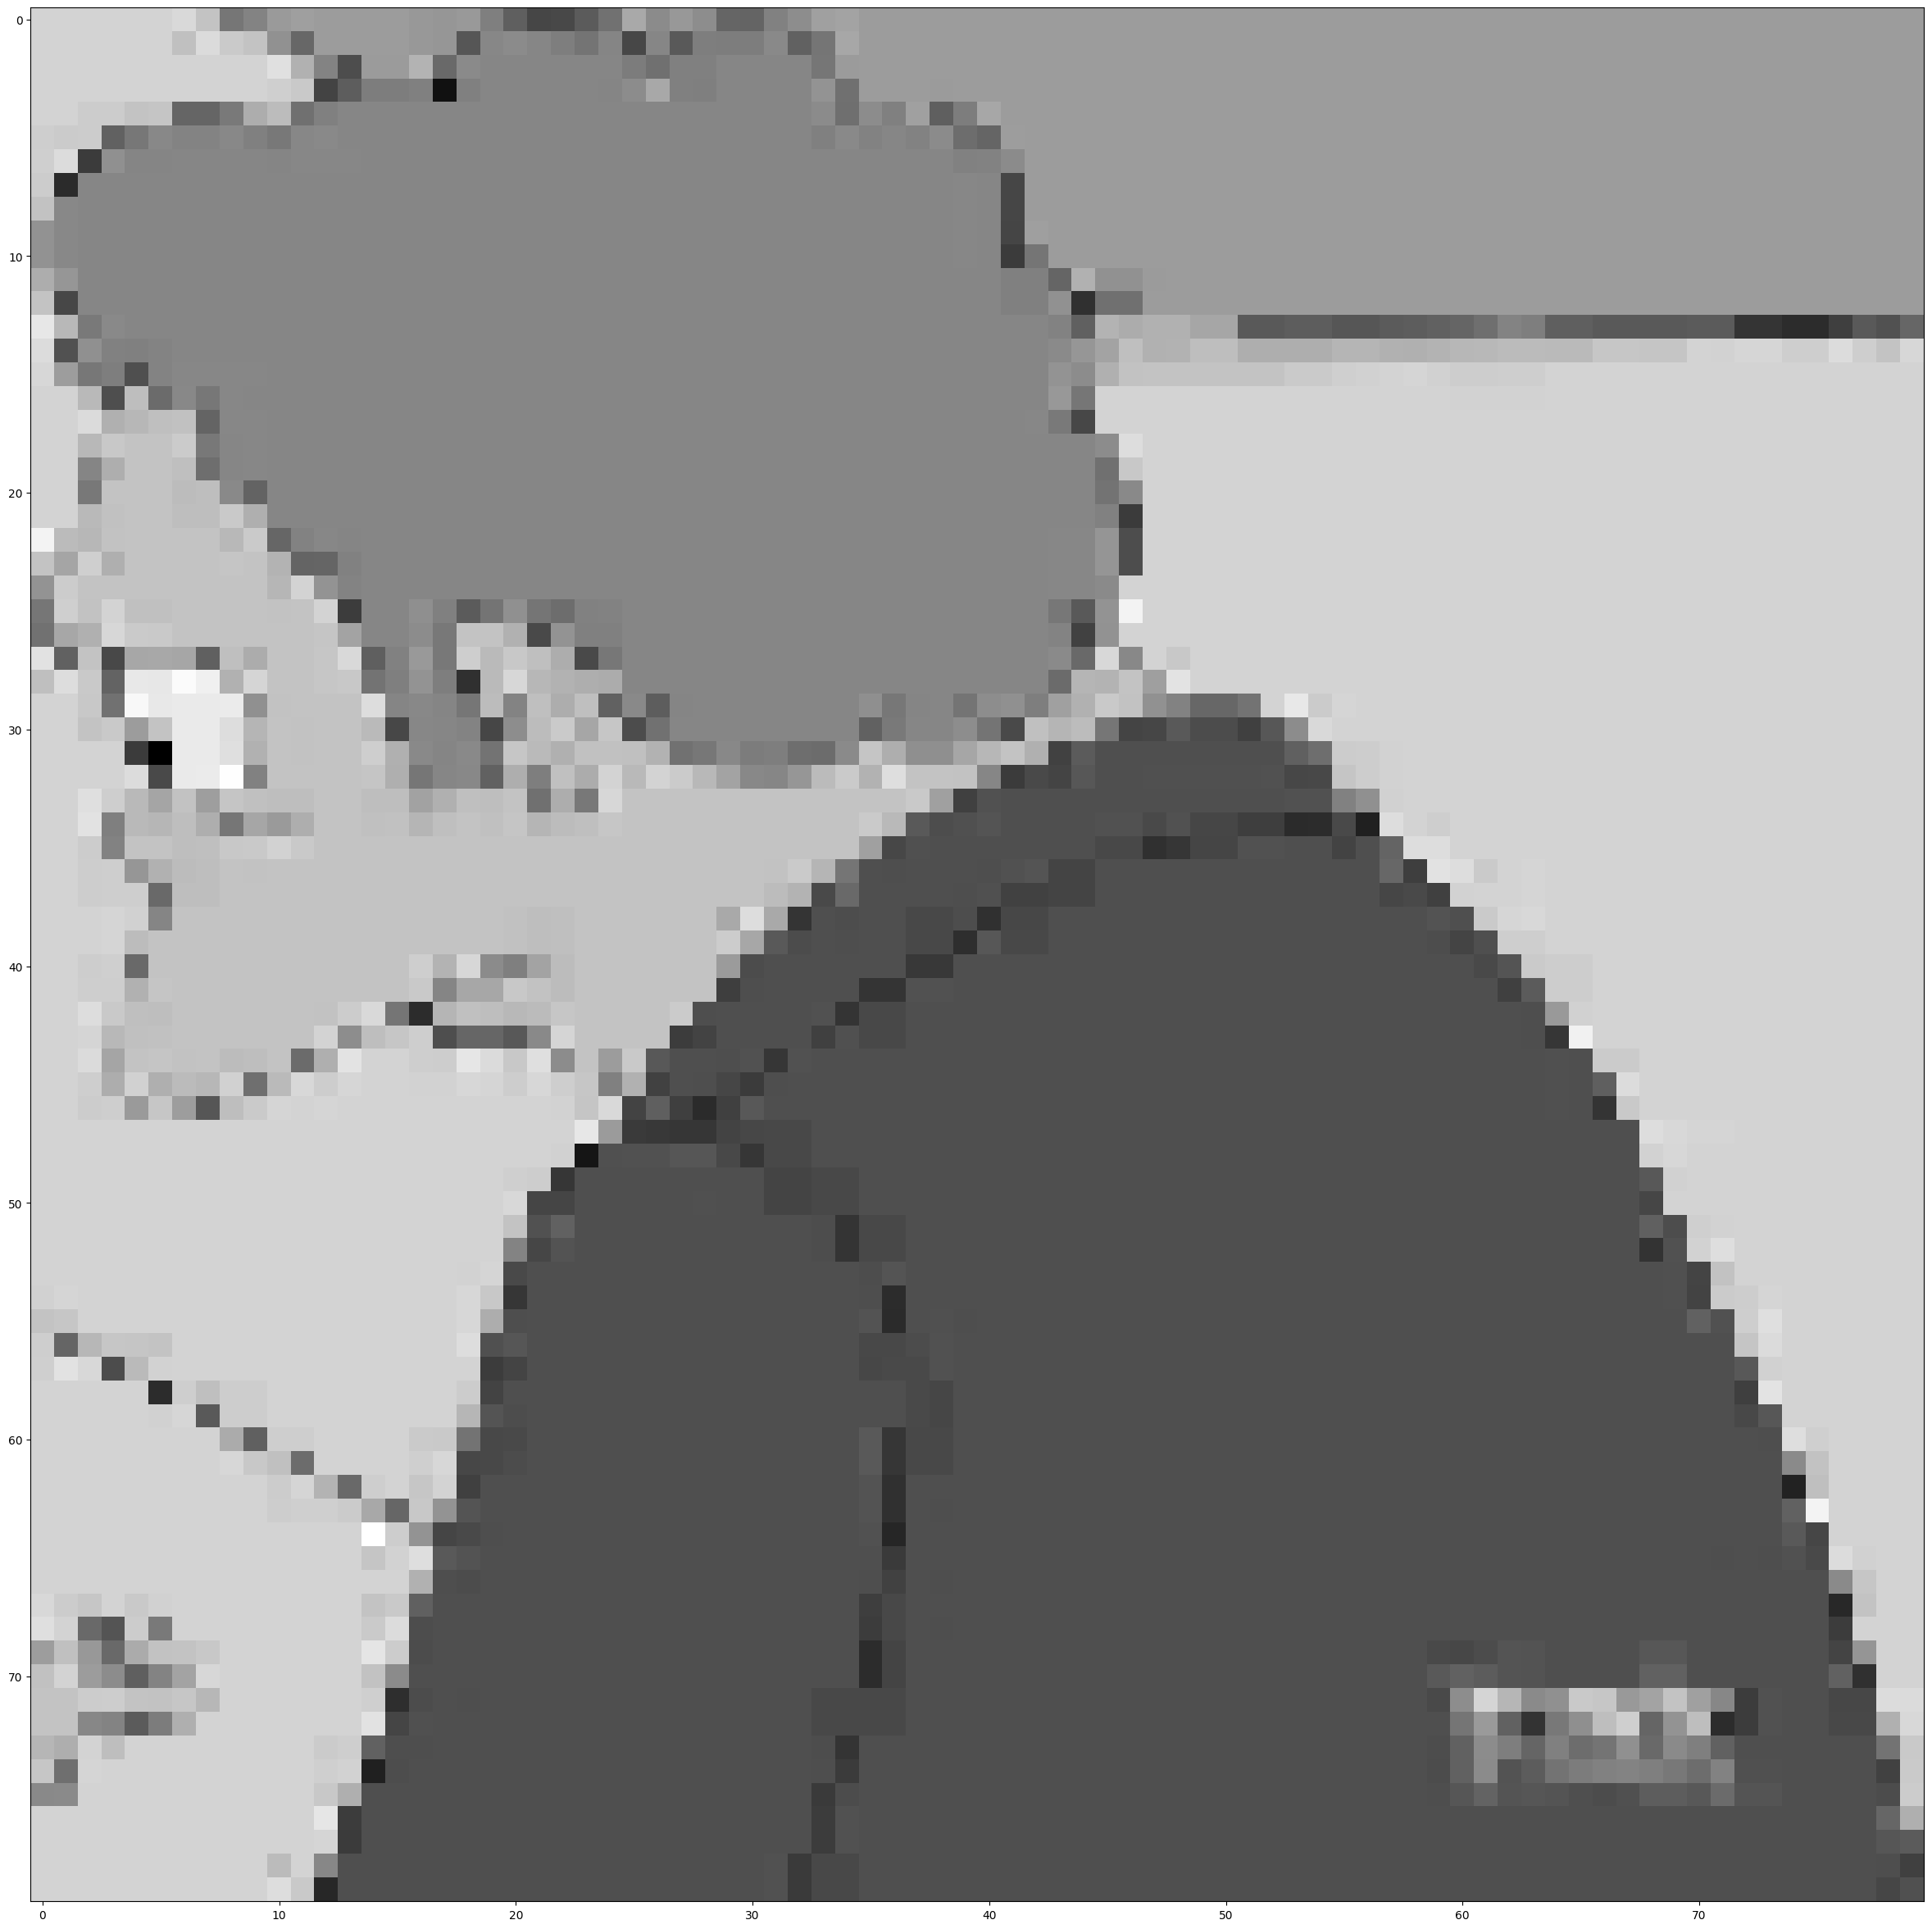

In [10]:
#  display img using matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 30))
plt.imshow(train[0][0], cmap='gray')
plt.show()

In [11]:
#  sptiiting training set into features and labels

featureSet, labels = caer.sep_train(train, IMG_SIZE=img_size)


In [12]:
#  normalizing the featureset data to be in range of ( 0 , 1) to learn features faster

from tensorflow.keras.utils import to_categorical

featureSet = caer.normalize(featureSet)

#  converting integers to binary class vectors
labels = to_categorical(labels, len(characters))


2026-02-07 11:16:42.005194: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770463002.415623      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770463002.530683      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770463003.518699      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770463003.518745      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770463003.518748      24 computation_placer.cc:177] computation placer alr

In [13]:
x_train, x_val, y_train, y_val = caer.train_val_split(featureSet, labels, val_ratio = 2)

In [14]:
#  removing unwamted columns
# del train
# del featureSet
# del labels
# gc.collect()

In [15]:
#  Image data generator (if using  GPU ) 

# datagen = canaro.generators.imageDataGenerator()

# BATCH_SIZE = 32
# EPOCHS = 10
# train_gen = datagen.flow(x_train, y_train, batch_size=BATCH_SIZE)
# ========================================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define the Generator with Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,      # Randomly rotate images
    width_shift_range=0.1,  # Randomly shift images horizontally
    height_shift_range=0.1, # Randomly shift images vertically
    zoom_range=0.1,         # Randomly zoom in/out
    horizontal_flip=True,   # Flip images horizontally
    fill_mode='nearest'
)

# 2. Set your hyperparameters
BATCH_SIZE = 32
EPOCHS = 10

# 3. Create the training generator  
train_gen = datagen.flow(featureSet, labels, batch_size=BATCH_SIZE)

In [16]:
#  Creating model

# model = canaro.models.createSimpsonsModel(IMG_SIZE=img_size, 
#                                           channels=channels, 
#                                           output_dims=len(characters), 
#                                           loss='binary_crossentropy', 
#                                           decay=1e-6, 
#                                           learning_rate=0.001, 
#                                           momentum=0.9, 
#                                           nesterov=True)

# # model.summary()
# ------------------------------------------------------------------------------------

from tensorflow.keras import layers, models, optimizers

def create_simpsons_model(img_size, channels, output_dims):
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_size[0], img_size[1], channels)),
        layers.MaxPooling2D((2, 2)),
        
        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Fully Connected Layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(output_dims, activation='softmax')
    ])
    
    # Matching the specific optimizer settings from your Cell 15
    optimizer = optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)
    
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Now initialize the model using your notebook's variables
model = create_simpsons_model(img_size=img_size, channels=channels, output_dims=len(characters))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1770463026.641563      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770463026.644728      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 80, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,372,298 (12.86 MB)

 Trainable params: 3,372,298 (12.86 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:

# from tenserflow.keras.callbacks import LearningRateScheduler

# callbacks_list = [LearningRateScheduler(canaro.lr_schedule)]

from tensorflow.keras.callbacks import LearningRateScheduler

# Simple step decay function to replace the missing canaro utility
def lr_schedule(epoch):
    lr = 0.001
    if epoch > 5:
        lr *= 0.1
    return lr

callbacks_list = [LearningRateScheduler(lr_schedule)]

In [18]:

#  training the model
training = model.fit( train_gen, 
                        steps_per_epoch=len(x_train)//BATCH_SIZE, 
                        epochs=EPOCHS, 
                        validation_data=(x_val, y_val), 
                        validation_steps=len(y_val)//BATCH_SIZE, 
                        callbacks = callbacks_list
                        )


characters



Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1770463029.734360      85 service.cc:152] XLA service 0x7980c8005170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770463029.734411      85 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770463029.734415      85 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770463030.097883      85 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/432 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.1303 - loss: 2.3063

I0000 00:00:1770463034.586914      85 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


432/432 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.1479 - loss: 2.2848 - val_accuracy: 0.1627 - val_loss: 2.2463 - learning_rate: 0.0010
Epoch 2/10
  4/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.1400 - loss: 2.2492 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


432/432 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.1824 - loss: 2.2355 - val_accuracy: 0.2434 - val_loss: 2.1624 - learning_rate: 0.0010
Epoch 3/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.2074 - loss: 2.1758 - val_accuracy: 0.2414 - val_loss: 2.0838 - learning_rate: 0.0010
Epoch 4/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.2435 - loss: 2.1198 - val_accuracy: 0.2772 - val_loss: 2.0348 - learning_rate: 0.0010
Epoch 5/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.2669 - loss: 2.0953 - val_accuracy: 0.3172 - val_loss: 2.0021 - learning_rate: 0.0010
Epoch 6/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.2722 - loss: 2.0682 - val_accuracy: 0.3279 - val_loss: 1.9622 - learning_rate: 0.0010
Epoch 7/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.2835 - loss: 2.0356 - val_accuracy: 0.3351 - val_loss: 1.9401 - learning_rate: 1.0000e-04
Epoch 8/10
432/432 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.2963 - loss: 2.

['homer_simpson',
 'ned_flanders',
 'moe_szyslak',
 'lisa_simpson',
 'bart_simpson',
 'marge_simpson',
 'krusty_the_clown',
 'principal_skinner',
 'charles_montgomery_burns',
 'milhouse_van_houten']

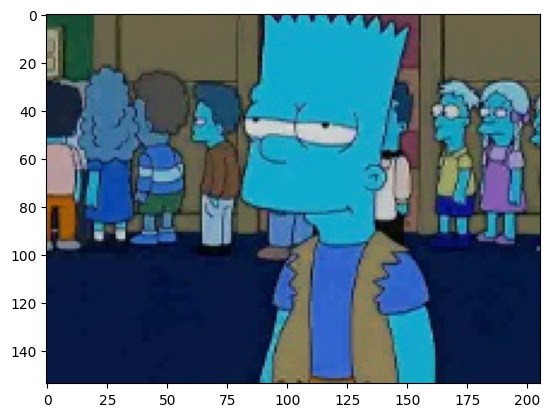

In [19]:

#  testing the model
#  Brat Simpson

test_path = r'/kaggle/input/the-simpsons-characters-dataset/kaggle_simpson_testset/kaggle_simpson_testset/bart_simpson_19.jpg'

img = cv.imread(test_path)
plt.imshow(img, cmap='gray')
plt.show()

def prepareModel(img):
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img = cv.resize(img, img_size)
    img = caer.reshape(img, img_size, 1)
    
    return img


In [20]:

#  predictions
predictions = model.predict(prepareModel(img))

predictions

print(characters[np.argmax(predictions[0] )])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
lisa_simpson


In [21]:
import tensorflow as tf

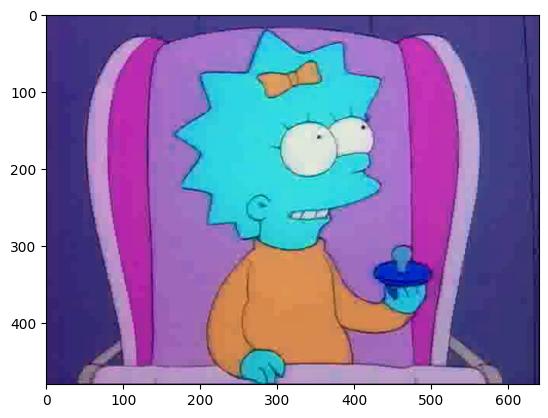

In [22]:
#  testing the model
#  Maggie_simpson

test_path = r'/kaggle/input/the-simpsons-characters-dataset/simpsons_dataset/maggie_simpson/pic_0029.jpg'

img = cv.imread(test_path)
plt.imshow(img, cmap='gray')
plt.show()

def prepareModel(img):
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img = cv.resize(img, img_size)
    img = caer.reshape(img, img_size, 1)
    
    return img


In [23]:
#  predictions
predictions = model.predict(prepareModel(img))

predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [24]:
print(characters[np.argmax(predictions[0] )])

lisa_simpson
